# **Global Vaccination Data Analysis and Visualization**

##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual/ Sita Bharatula
##### **Domain** - Public Health and Epidemiology

# **Project Summary -**

This project analyzes five linked WHO/UNICEF global immunization datasets — **vaccination coverage**, **disease incidence rates**, **reported case counts**, **vaccine introduction status**, and **vaccine schedules** — spanning **214 countries** and the years **1980–2023**, covering **69 distinct antigens/vaccines** and **13 vaccine-preventable diseases**.

The datasets were cleaned (removing footer/blank rows, standardizing types, separating country-level records from WHO-region and global aggregate records) and then explored to answer the "Easy" and "Medium" level analytical questions defined in the project brief: coverage trends over time, dose-1-to-dose-3 drop-off, booster uptake, regional disparities, vaccine-introduction timelines across WHO regions, and the relationship between coverage and disease incidence.

Key findings: global DTP3/MCV1/POL3 coverage climbed steadily from the low-70s (%) in 2000 to the mid-80s by 2019, then **dropped 3–5 points during 2020–2021 (COVID-19 disruption)** and has only partially recovered by 2023. The DTP1→DTP3 drop-off (a proxy for programme retention) narrowed from 6 points in 2009 to 4 points in 2018 before widening again post-pandemic. Measles second-dose (booster) coverage nearly doubled from 40% (2009) to 74% (2023), showing steady programmatic maturation. Regionally, the **African Region trails all other WHO regions on DTP3 coverage (74% vs. a 95% European Region)**, and new vaccines (e.g., Rotavirus) reach African countries faster than European ones — highlighting that *introduction* and *sustained coverage* are two different problems. Coverage and incidence are negatively correlated as expected (e.g., DTP3 vs. Pertussis r ≈ -0.23, MCV1 vs. Measles r ≈ -0.20), but several countries with ≥90% reported coverage (e.g., Samoa, Madagascar, DR Congo, Ukraine) still experienced major measles outbreaks — a signal of either data-reporting gaps, outbreak importation, or coverage that is nominally high but unevenly distributed sub-nationally.

**Important data limitation:** the five source tables contain no gender, education-level, urban/rural, income/socioeconomic, population-density, or sub-annual (monthly) fields, so several brief questions (gender gap, education impact, urban vs. rural, seasonality, population density) **cannot be answered from this dataset** and are flagged as such rather than guessed at.

# **GitHub Link -**

https://github.com/maha2806/Ds--Vaccination-project.git

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. Data is cleaned here in Python; the cleaned tables are designed to be loaded into a SQL database and connected to Power BI for interactive dashboards that support public-health strategy, disease prevention, resource allocation, and global health policy decisions (see the companion **Power BI Dashboard & Business Report**).

#### **Define Your Business Objective?**

Identify where vaccination programmes are working, where they are falling behind (by region, vaccine, and dose number), and where reported coverage does not translate into disease control — so that health agencies can target resources, close drop-off and booster gaps, and track progress toward the WHO 95%-coverage goal.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PAL = ["#1B4965", "#5FA8D3", "#2A9D8F", "#F4A261", "#E76F51", "#8E44AD"]
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)

### Dataset Loading

In [2]:
# All five datasets share a 'Data' sheet (analysis-ready) and a 'Reference' sheet (code books / metadata)
PATHS = {
    "coverage": "coverage-data.xlsx",
    "incidence": "incidence-rate-data.xlsx",
    "cases": "reported-cases-data.xlsx",
    "intro": "vaccine-introduction-data.xlsx",
    "schedule": "vaccine-schedule-data.xlsx",
}

raw = {name: pd.read_excel(path, sheet_name="Data") for name, path in PATHS.items()}
for name, df in raw.items():
    print(f"{name:10s} -> {df.shape[0]:>7,} rows x {df.shape[1]} cols")

coverage   -> 399,859 rows x 11 cols
incidence  ->  84,946 rows x 8 cols
cases      ->  84,870 rows x 7 cols
intro      -> 138,321 rows x 6 cols
schedule   ->   8,053 rows x 12 cols


### Dataset First View

In [3]:
for name, df in raw.items():
    print("="*90, f"\n{name.upper()}\n", "="*90, sep="")
    display(df.head(3))

COVERAGE


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52


INCIDENCE


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3


CASES


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0


INTRO


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes


SCHEDULE


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [4]:
shape_summary = pd.DataFrame({name: [df.shape[0], df.shape[1]] for name, df in raw.items()},
                              index=["rows", "columns"]).T
shape_summary

,rows,columns
coverage,399859,11
incidence,84946,8
cases,84870,7
intro,138321,6
schedule,8053,12


### Dataset Information

In [5]:
for name, df in raw.items():
    print("="*60, f"\n{name.upper()} — dtypes & non-null counts\n", "="*60, sep="")
    df.info()
    print()

COVERAGE — dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  object 
 1   CODE                           399858 non-null  object 
 2   NAME                           398584 non-null  object 
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  object 
 5   ANTIGEN_DESCRIPTION            399858 non-null  object 
 6   COVERAGE_CATEGORY              399858 non-null  object 
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  object 
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), object(7)
memory usage: 33.6+ MB

INCIDE

#### Duplicate Values

In [6]:
for name, df in raw.items():
    print(f"{name:10s} duplicate rows: {df.duplicated().sum():,}")

coverage   duplicate rows: 0
incidence  duplicate rows: 0
cases      duplicate rows: 0
intro      duplicate rows: 0
schedule   duplicate rows: 0


#### Missing Values/Null Values

In [7]:
for name, df in raw.items():
    print("="*60, f"\n{name.upper()}\n", "="*60, sep="")
    print(df.isnull().sum())
    print()

COVERAGE
GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

INCIDENCE
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

CASES
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES                  19400
dtype: int64

INTRO
ISO_3_CODE     0
COUNTRYNAME    1
WHO_REGION     1
Y

**Note:** every table ends in a single fully-blank / footer row (an artifact of the Excel export) which drives the "1 missing value in every column" pattern seen above — this is removed in Data Wrangling below. Beyond that, the real missingness lives in `TARGET_NUMBER`, `DOSES`, and `COVERAGE` in the coverage table (administrative counts are not reported by every country/year/vaccine combination), and in `INCIDENCE_RATE` / `CASES` where a disease was not under surveillance in a given country-year.

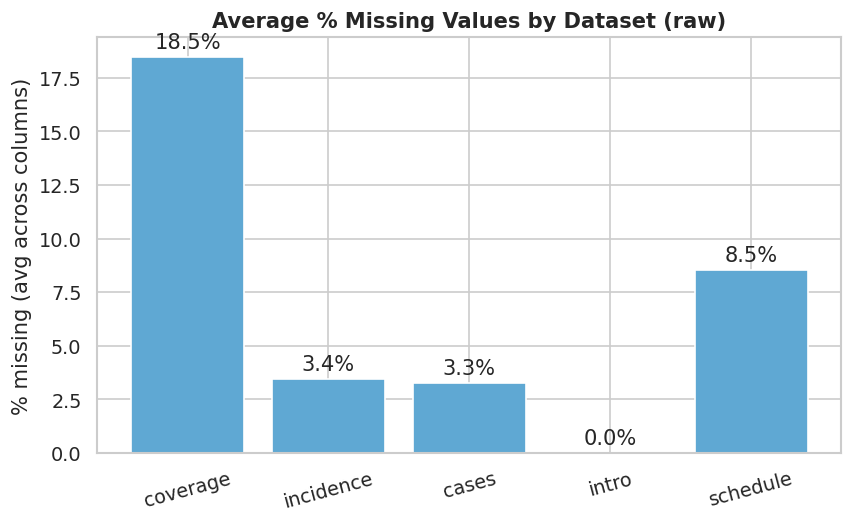

In [8]:
fig, ax = plt.subplots(figsize=(8,4.5))
miss_pct = {name: df.isnull().mean().mean()*100 for name, df in raw.items()}
bars = ax.bar(miss_pct.keys(), miss_pct.values(), color=PAL[1])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Average % Missing Values by Dataset (raw)", fontweight="bold")
ax.set_ylabel("% missing (avg across columns)")
plt.xticks(rotation=15)
plt.show()

### What did you know about your dataset?

- **5 linked tables**, joinable on `CODE`/`ISO_3_CODE` (country) + `YEAR`, and further on `ANTIGEN`/`DISEASE`/`VACCINECODE`.
- **coverage-data**: ~400K rows, country + WHO-region + global aggregate rows mixed together (`GROUP` column), 69 antigens, 1980–2023.
- **incidence-rate-data** & **reported-cases-data**: ~85K rows each, 13 diseases, 1980–2023, incidence normalized by a stated denominator (e.g. per 1,000,000 population, per 10,000 live births) — the denominator is *not* constant across diseases, so raw incidence rates are not directly comparable across diseases without noting the denominator.
- **vaccine-introduction-data**: ~138K rows, binary Yes/No per country-year-vaccine — good for timeline/disparity analysis.
- **vaccine-schedule-data**: ~8K rows, 2019–2023 only, one row per dose/round per country — good for understanding *how many doses* each country's schedule calls for, not for long-run trends.
- No demographic breakdown fields exist anywhere (no gender, age band beyond "age administered", education, urban/rural, income, or population density), and no sub-annual date field — several brief questions are therefore out of scope for this data and are called out explicitly rather than approximated.

## ***2. Understanding Your Variables***

In [9]:
for name, df in raw.items():
    print(name.upper(), "columns:", list(df.columns))

COVERAGE columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
INCIDENCE columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
CASES columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
INTRO columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
SCHEDULE columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [10]:
raw["coverage"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354065,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0


### Variables Description

| Table | Key variables |
|---|---|
| **coverage** | `GROUP/CODE/NAME` (country or aggregate), `YEAR`, `ANTIGEN`/`ANTIGEN_DESCRIPTION`, `COVERAGE_CATEGORY` (admin/official/WUENIC), `TARGET_NUMBER`, `DOSES`, `COVERAGE` (%) |
| **incidence** | `CODE/NAME`, `YEAR`, `DISEASE`/`DISEASE_DESCRIPTION`, `DENOMINATOR` (population basis), `INCIDENCE_RATE` |
| **cases** | `CODE/NAME`, `YEAR`, `DISEASE`/`DISEASE_DESCRIPTION`, `CASES` (raw count) |
| **intro** | `ISO_3_CODE/COUNTRYNAME`, `WHO_REGION`, `YEAR`, `DESCRIPTION` (vaccine), `INTRO` (Yes/No) |
| **schedule** | `ISO_3_CODE/COUNTRYNAME`, `WHO_REGION`, `YEAR`, `VACCINECODE/VACCINE_DESCRIPTION`, `SCHEDULEROUNDS` (dose #), `TARGETPOP`, `AGEADMINISTERED` |

### Check Unique Values for each variable.

In [11]:
print("Coverage - GROUP levels:", raw['coverage']['GROUP'].dropna().unique())
print("Coverage - # antigens:", raw['coverage']['ANTIGEN'].nunique())
print("Incidence - diseases:", raw['incidence']['DISEASE'].dropna().unique())
print("Intro - WHO regions:", raw['intro']['WHO_REGION'].dropna().unique())
print("Coverage - # countries (GROUP=='COUNTRIES'):", raw['coverage'].loc[raw['coverage']['GROUP']=='COUNTRIES','NAME'].nunique())

Coverage - GROUP levels: ['COUNTRIES' 'DEVELOPMENT_STATUS' 'GAVI_PHASE5' 'GLOBAL' 'UNICEF_REGIONS'
 'WB_LONG' 'WB_SHORT' 'WHO_REGIONS' 'Created: 2025-02-01 16:00 UTC']
Coverage - # antigens: 69
Incidence - diseases: ['CRS' 'DIPHTHERIA' 'INVASIVE_MENING' 'MEASLES' 'MUMPS' 'NTETANUS'
 'PERTUSSIS' 'POLIO' 'RUBELLA' 'TTETANUS' 'TYPHOID' 'YFEVER' 'JAPENC']
Intro - WHO regions: ['EMRO' 'AFRO' 'EURO' 'AMRO' 'WPRO' 'SEARO']
Coverage - # countries (GROUP=='COUNTRIES'): 214


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
def clean(df):
    df = df.dropna(how="all")                 # drop fully-blank trailing row
    df = df.dropna(subset=[df.columns[0]])     # drop stray footer row
    df.columns = [c.strip().upper() for c in df.columns]
    if "YEAR" in df.columns:
        df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")
    return df.drop_duplicates()

data = {name: clean(df) for name, df in raw.items()}

# Coverage table mixes country rows with WHO-region / global aggregate rows -> split them out
cov_country = data["coverage"][data["coverage"]["GROUP"] == "COUNTRIES"].copy()
cov_region  = data["coverage"][data["coverage"]["GROUP"] == "WHO_REGIONS"].copy()
cov_global  = data["coverage"][data["coverage"]["GROUP"] == "GLOBAL"].copy()

inc, cases, intro, sched = data["incidence"], data["cases"], data["intro"], data["schedule"]

for name, df in {"cov_country": cov_country, "cov_region": cov_region, "cov_global": cov_global,
                  "incidence": inc, "cases": cases, "intro": intro, "schedule": sched}.items():
    print(f"{name:12s} -> {df.shape}")

cov_country  -> (381041, 11)
cov_region   -> (3757, 11)
cov_global   -> (645, 11)
incidence    -> (84946, 8)
cases        -> (84870, 7)
intro        -> (138321, 6)
schedule     -> (8053, 12)


### What all manipulations have you done and insights you found?

1. Dropped the trailing blank/footer row present in every source sheet.
2. Standardized column names to upper-case for consistent joins across the five tables.
3. Cast `YEAR` to a nullable integer type.
4. **Split the coverage table by `GROUP`** into country-level (`cov_country`), WHO-region aggregate (`cov_region`), and global aggregate (`cov_global`) subsets — mixing these in a "% coverage" average would silently double count and distort results, since region/global rows are themselves aggregates of the country rows.
5. Removed exact duplicate rows (none were found beyond the footer row, i.e. the source data is already row-unique).
6. Left `TARGET_NUMBER`/`DOSES`/`COVERAGE` missing values as `NaN` (not imputed) — for public-health reporting, a missing coverage value means *not reported that year*, and imputing a percentage would fabricate a claim about a country's programme. Downstream aggregations use `dropna()`/`aggfunc='mean'`, which naturally excludes unreported cells.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: Global Coverage Trend for Key Antigens (2000–2023)

_Easy Q: Has coverage risen or fallen over time / is there a seasonal or long-run pattern?_

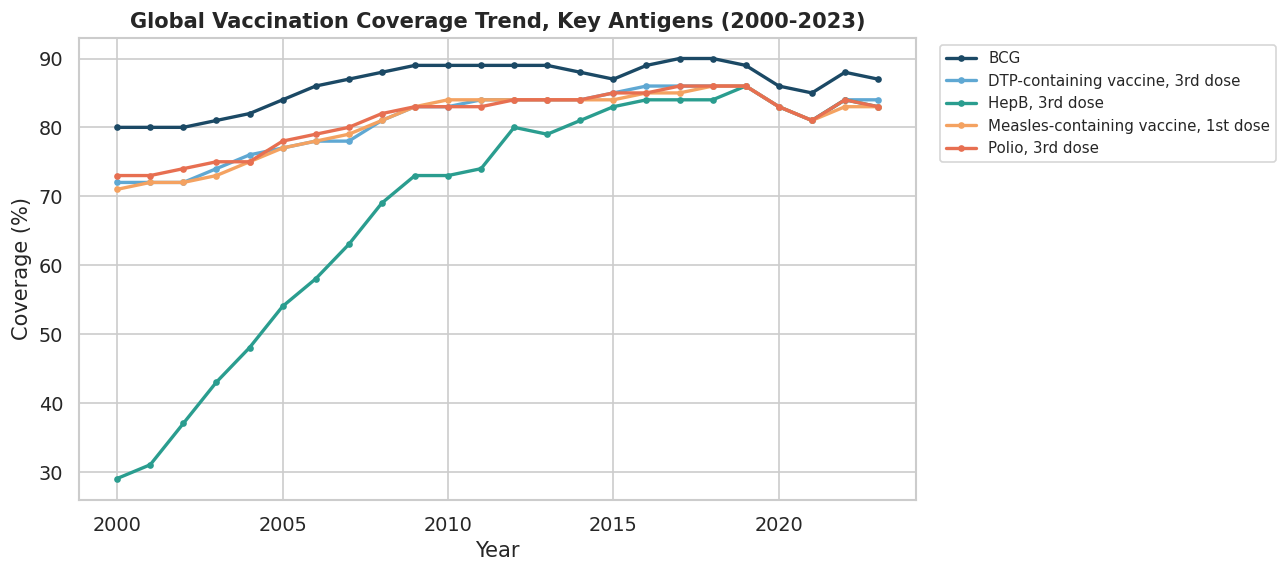

In [13]:
# Chart - 1: Global Coverage Trend for Key Antigens (2000–2023) visualization code
g = cov_global[cov_global["ANTIGEN"].isin(["DTPCV3","MCV1","POL3","BCG","HEPB3"])]
g = g[g["YEAR"] >= 2000]
piv = g.pivot_table(index="YEAR", columns="ANTIGEN_DESCRIPTION", values="COVERAGE", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9,5))
piv.plot(ax=ax, marker="o", ms=3, linewidth=2, color=PAL)
ax.set_title("Global Vaccination Coverage Trend, Key Antigens (2000-2023)", fontweight="bold")
ax.set_ylabel("Coverage (%)"); ax.set_xlabel("Year")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=9)
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line time trend is the clearest way to show direction, rate of change, and shocks (e.g. COVID-19) simultaneously across several vaccines on a shared axis.

##### 2. What is/are the insight(s) found from the chart?

Global coverage for DTP3/MCV1/POL3/HEPB3 climbed from the low-to-mid 70s in 2000 to the mid-to-high 80s by 2019 — then all five antigens **dropped 3-5 percentage points in 2020-2021** during the pandemic, and coverage in 2023 (~83-87%) has still not returned to the 2019 peak.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive use: shows steady long-run programme improvement, justifying continued investment. Negative signal: the pandemic-era backslide has **not fully recovered**, meaning millions of "zero-dose" children remain — this should trigger catch-up campaign funding, which is exactly the kind of decision this analysis is meant to support.

#### Chart - 2: DTP Dose-1 → Dose-3 Drop-off

_Easy Q: What is the drop-off rate between 1st dose and subsequent doses?_

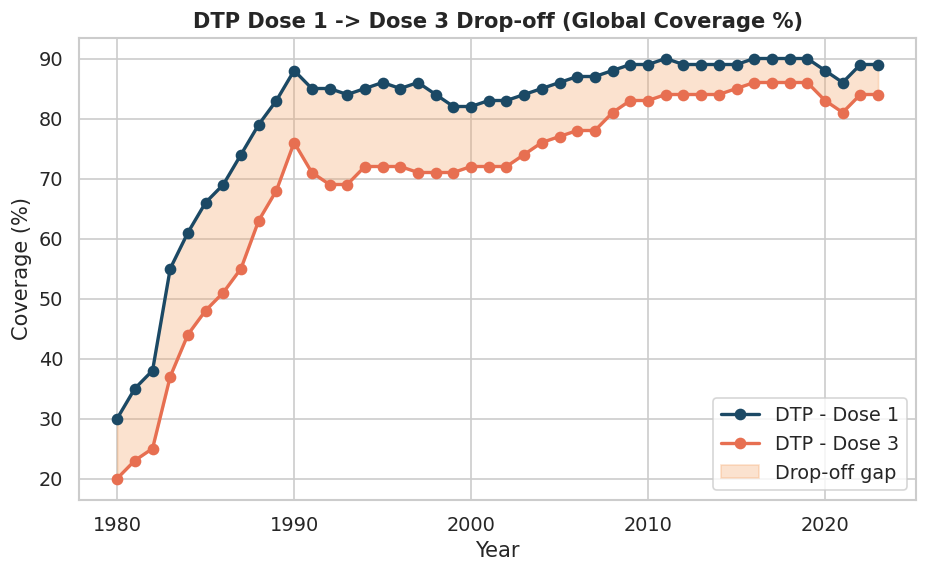

In [14]:
# Chart - 2: DTP Dose-1 → Dose-3 Drop-off visualization code
dtp = cov_global[cov_global["ANTIGEN"].isin(["DTPCV1","DTPCV3"])]
dtp_piv = dtp.pivot_table(index="YEAR", columns="ANTIGEN", values="COVERAGE", aggfunc="mean").dropna()

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(dtp_piv.index, dtp_piv["DTPCV1"], marker="o", label="DTP - Dose 1", color=PAL[0], linewidth=2)
ax.plot(dtp_piv.index, dtp_piv["DTPCV3"], marker="o", label="DTP - Dose 3", color=PAL[4], linewidth=2)
ax.fill_between(dtp_piv.index, dtp_piv["DTPCV1"], dtp_piv["DTPCV3"], color=PAL[3], alpha=0.3, label="Drop-off gap")
ax.set_title("DTP Dose 1 -> Dose 3 Drop-off (Global Coverage %)", fontweight="bold")
ax.set_ylabel("Coverage (%)"); ax.set_xlabel("Year"); ax.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A filled band between two lines is a direct visual read of a 'gap' metric (the drop-off), which is more intuitive than a separate derived bar chart for a two-series comparison.

##### 2. What is/are the insight(s) found from the chart?

Global drop-off between Dose 1 and Dose 3 narrowed from **6 percentage points in 2009 to 4 points in 2016-2019**, showing programmes retaining children better through the full schedule — then widened back to **5 points in 2021-2023**, mirroring the pandemic disruption seen in Chart 1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: a shrinking gap 2009-2019 is a genuine programmatic win (better follow-up, reminder systems, health-worker retention). Negative: the post-2020 widening means more children start but don't finish the schedule — a target for reminder-call / home-visit interventions rather than new vaccine introduction.

#### Chart - 3: Measles Booster (2nd Dose) Uptake Trend

_Easy Q: Has the rate of booster dose uptake increased over time?_

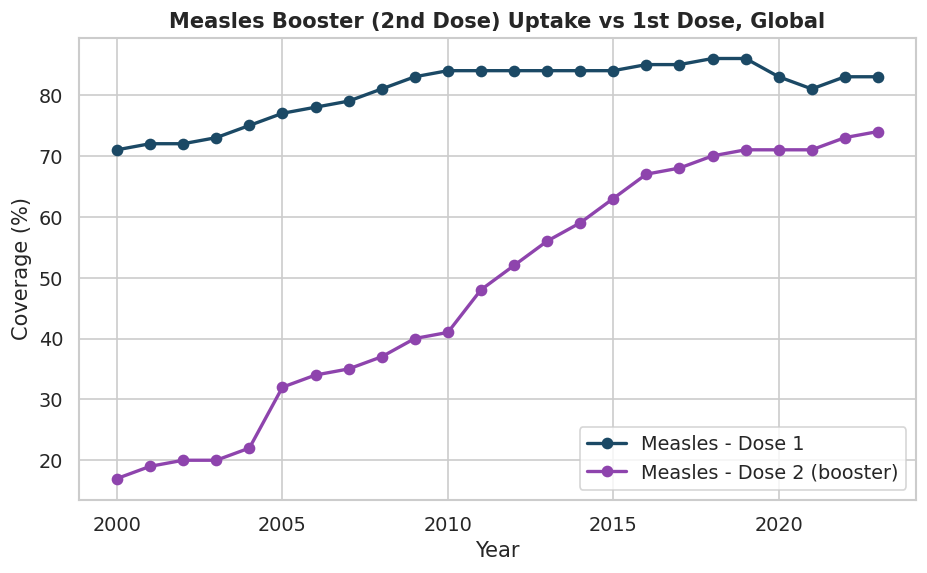

In [15]:
# Chart - 3: Measles Booster (2nd Dose) Uptake Trend visualization code
mcv = cov_global[cov_global["ANTIGEN"].isin(["MCV1","MCV2"])]
mcv_piv = mcv.pivot_table(index="YEAR", columns="ANTIGEN", values="COVERAGE", aggfunc="mean").dropna()

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(mcv_piv.index, mcv_piv["MCV1"], marker="o", label="Measles - Dose 1", color=PAL[0], linewidth=2)
ax.plot(mcv_piv.index, mcv_piv["MCV2"], marker="o", label="Measles - Dose 2 (booster)", color=PAL[5], linewidth=2)
ax.set_title("Measles Booster (2nd Dose) Uptake vs 1st Dose, Global", fontweight="bold")
ax.set_ylabel("Coverage (%)"); ax.set_xlabel("Year"); ax.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Two converging lines make it easy to see a gap closing over time — directly answering 'has uptake increased' as a trend, not just a single before/after number.

##### 2. What is/are the insight(s) found from the chart?

Measles 2nd-dose (booster) coverage nearly **doubled from 40% (2009) to 74% (2023)**, while 1st-dose coverage stayed roughly flat (83-86%) — the gap between dose 1 and the booster has closed from 43 points to under 10 points, i.e. booster programmes are maturing fast.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strongly positive: closing the 1st/2nd dose gap for measles directly reduces outbreak risk, since a single dose leaves ~15% of children susceptible. This supports continued global investment in 2nd-dose delivery specifically (not just 1st-dose outreach).

#### Chart - 4: DTP3 Coverage by WHO Region (latest year)

_Easy/Medium Q: Regional disparities — which regions have low coverage or high incidence despite high coverage elsewhere?_

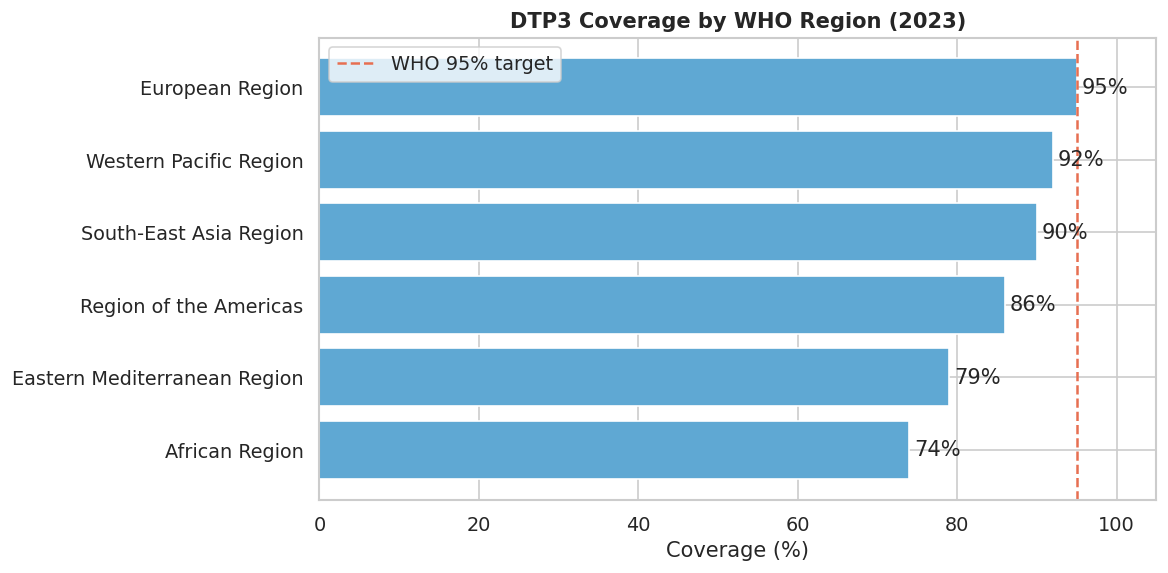

In [16]:
# Chart - 4: DTP3 Coverage by WHO Region (latest year) visualization code
latest_year = cov_region["YEAR"].max()
reg = cov_region[(cov_region["ANTIGEN"]=="DTPCV3") & (cov_region["YEAR"]==latest_year)].sort_values("COVERAGE")

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(reg["NAME"], reg["COVERAGE"], color=PAL[1])
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.axvline(95, color=PAL[4], linestyle="--", linewidth=1.5, label="WHO 95% target")
ax.set_title(f"DTP3 Coverage by WHO Region ({int(latest_year)})", fontweight="bold")
ax.set_xlabel("Coverage (%)"); ax.set_xlim(0,105); ax.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A sorted horizontal bar chart ranks regions cleanly and a reference line makes the policy target (95%) immediately visible against every bar.

##### 2. What is/are the insight(s) found from the chart?

The **African Region trails every other WHO region at 74% DTP3 coverage**, 21 points below the European Region (95%) and the only region still below the 95% target by a wide margin; South-East Asia (90%) and Western Pacific (92%) are closest to target after Europe.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive use: pinpoints exactly where global resource allocation should be concentrated (African Region) to move the needle on the global average fastest. No negative-growth read here — this is a straightforward prioritization signal.

#### Chart - 5: Rotavirus Vaccine Introduction Rate by WHO Region

_Medium Q: Are there significant disparities in vaccine introduction timelines across WHO regions?_

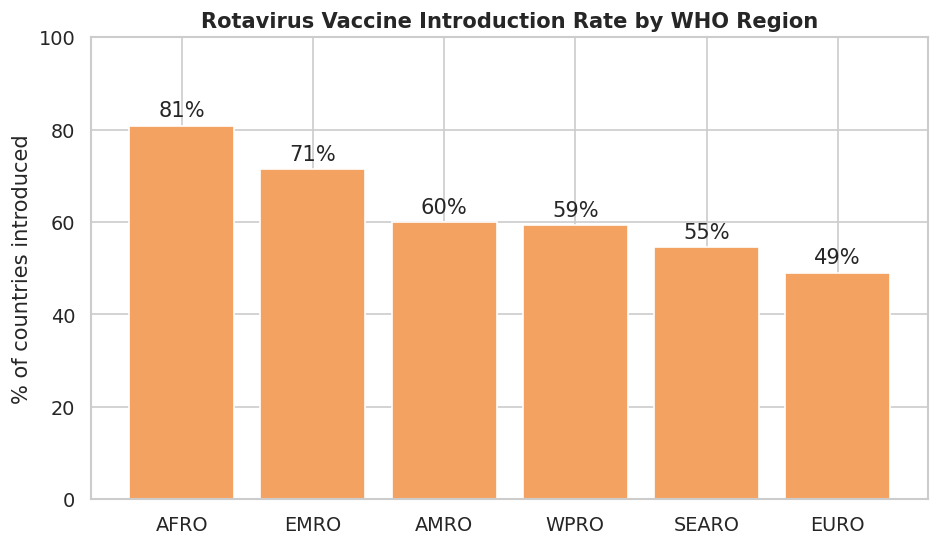

In [17]:
# Chart - 5: Rotavirus Vaccine Introduction Rate by WHO Region visualization code
rota_intro = intro[intro["DESCRIPTION"].str.contains("Rotavirus", case=False, na=False)]
rota_yes = rota_intro[rota_intro["INTRO"]=="Yes"]
by_region = rota_yes.groupby("WHO_REGION")["COUNTRYNAME"].nunique()
total_by_region = intro.groupby("WHO_REGION")["COUNTRYNAME"].nunique()
pct = (by_region/total_by_region*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(pct.index, pct.values, color=PAL[3])
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_title("Rotavirus Vaccine Introduction Rate by WHO Region", fontweight="bold")
ax.set_ylabel("% of countries introduced"); ax.set_ylim(0,100)
plt.show()

##### 1. Why did you pick the specific chart?

A simple ranked bar chart is the clearest way to compare one categorical metric (introduction %) across 6 regions.

##### 2. What is/are the insight(s) found from the chart?

Introduction disparities run the **opposite direction from coverage disparities**: the African Region has introduced Rotavirus vaccine in **81% of its countries** (highest of any region, thanks to Gavi-funded introduction support), while the European Region lags at **49%** — because many high-income European countries either rely on private-market vaccination or have not prioritized this specific antigen nationally.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important nuance for policy: 'introduced' ≠ 'high coverage'. A region can lead on getting a vaccine into its programme (AFRO) while still lagging on sustaining coverage of older staples like DTP3 (Chart 4) — resource allocation needs to separately track introduction and sustained delivery.

#### Chart - 6: DTP3 Coverage vs. Pertussis Incidence (country-years)

_Easy/Medium Q: How do vaccination rates correlate with a decrease in disease incidence?_

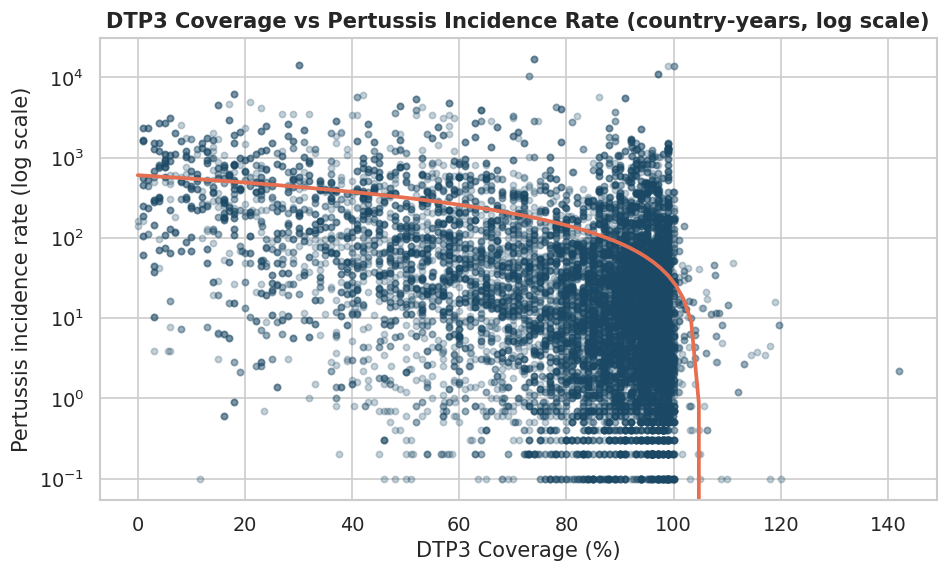

Pearson r: -0.227  n = 14470


In [18]:
# Chart - 6: DTP3 Coverage vs. Pertussis Incidence (country-years) visualization code
c = cov_country[cov_country["ANTIGEN"]=="DTPCV3"][["CODE","YEAR","COVERAGE"]].dropna()
i = inc[inc["DISEASE"]=="PERTUSSIS"][["CODE","YEAR","INCIDENCE_RATE"]].dropna()
m = c.merge(i, on=["CODE","YEAR"])
m = m[m["INCIDENCE_RATE"] > 0]

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(m["COVERAGE"], m["INCIDENCE_RATE"], alpha=0.25, s=14, color=PAL[0])
ax.set_yscale("log")
sns.regplot(x="COVERAGE", y="INCIDENCE_RATE", data=m, scatter=False, ax=ax, color=PAL[4], ci=None)
ax.set_title("DTP3 Coverage vs Pertussis Incidence Rate (country-years, log scale)", fontweight="bold")
ax.set_xlabel("DTP3 Coverage (%)"); ax.set_ylabel("Pertussis incidence rate (log scale)")
plt.show()

print("Pearson r:", round(m["COVERAGE"].corr(m["INCIDENCE_RATE"]), 3), " n =", len(m))

##### 1. Why did you pick the specific chart?

A log-scale scatter with a fitted trend line is the standard way to visualize a skewed count-like outcome (incidence) against a bounded percentage predictor (coverage), since incidence spans several orders of magnitude across countries.

##### 2. What is/are the insight(s) found from the chart?

There is a **modest negative correlation (r ≈ -0.23)** between DTP3 coverage and Pertussis incidence — higher coverage is associated with lower incidence, but the relationship is noisy: many low-incidence points exist across the whole coverage range, and several high-coverage countries still report non-trivial incidence, most likely due to under-vaccination of specific age cohorts, waning immunity, or improved surveillance detecting more true cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms coverage is doing real work reducing disease at the population level — supports continued investment. Caveat for negative growth: correlation is far from -1, so coverage alone won't fully explain or predict outbreaks; other factors (reporting quality, sub-national pockets of under-vaccination, waning immunity) must be investigated alongside coverage.

#### Chart - 7: MCV1 Coverage vs. Measles Incidence (country-years)

_Medium Q: How does vaccine coverage correlate with disease reduction for specific antigens?_

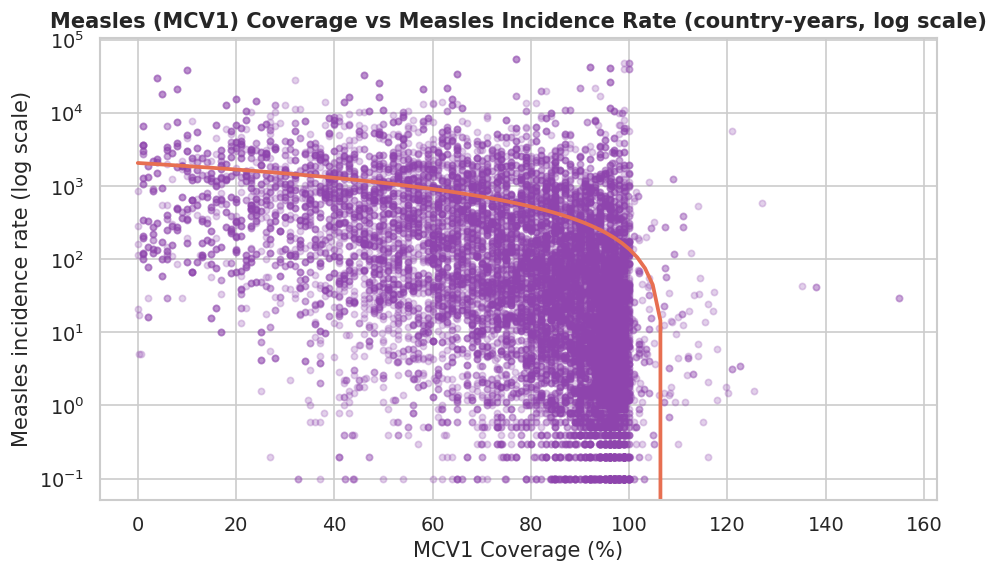

Pearson r: -0.192  n = 15972


In [19]:
# Chart - 7: MCV1 Coverage vs. Measles Incidence (country-years) visualization code
c = cov_country[cov_country["ANTIGEN"]=="MCV1"][["CODE","YEAR","COVERAGE"]].dropna()
i = inc[inc["DISEASE"]=="MEASLES"][["CODE","YEAR","INCIDENCE_RATE"]].dropna()
m2 = c.merge(i, on=["CODE","YEAR"])
m2 = m2[m2["INCIDENCE_RATE"] > 0]

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(m2["COVERAGE"], m2["INCIDENCE_RATE"], alpha=0.25, s=14, color=PAL[5])
ax.set_yscale("log")
sns.regplot(x="COVERAGE", y="INCIDENCE_RATE", data=m2, scatter=False, ax=ax, color=PAL[4], ci=None)
ax.set_title("Measles (MCV1) Coverage vs Measles Incidence Rate (country-years, log scale)", fontweight="bold")
ax.set_xlabel("MCV1 Coverage (%)"); ax.set_ylabel("Measles incidence rate (log scale)")
plt.show()

print("Pearson r:", round(m2["COVERAGE"].corr(m2["INCIDENCE_RATE"]), 3), " n =", len(m2))

##### 1. Why did you pick the specific chart?

Same log-scatter + trend-line approach as Chart 6, applied to measles specifically since it is the disease most sensitive to coverage gaps (herd-immunity threshold ~95%).

##### 2. What is/are the insight(s) found from the chart?

MCV1 coverage vs. Measles incidence shows **r ≈ -0.20**, weaker than the classic epidemiological expectation for measles given its ~95% herd-immunity threshold — this is explored further in Chart 13, which shows specific high-coverage / high-incidence outlier countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative-growth flag: because measles requires near-total (95%+) coverage to prevent outbreaks, a country sitting at 85-90% is *still* at real outbreak risk even though that looks like 'high' coverage on paper — dashboards should highlight the 95% herd-immunity threshold explicitly, not just show coverage as 'good' once it crosses 80-90%.

#### Chart - 8: Global Reported Cases Over Time, Key Diseases

_Medium Q: What is the trend in disease cases before and after vaccination campaigns?_

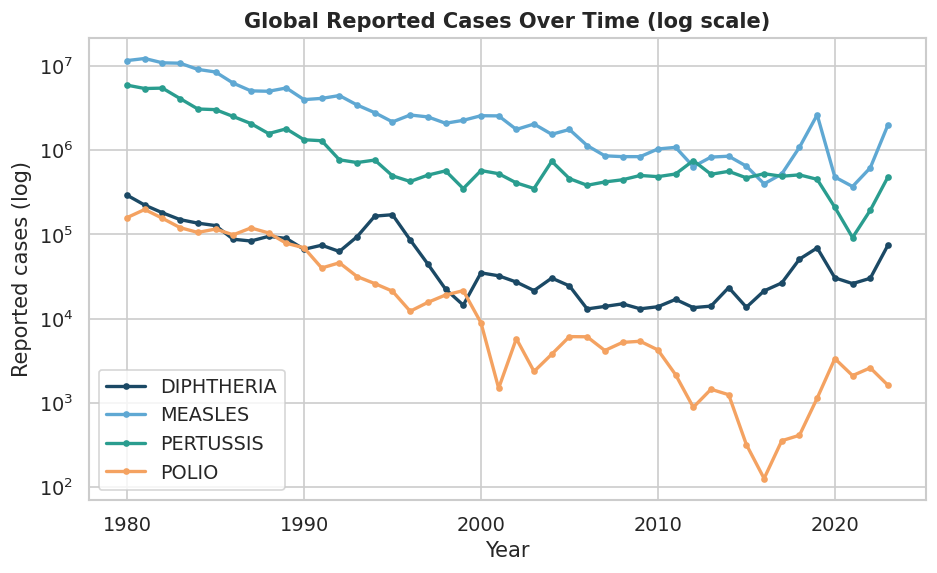

In [20]:
# Chart - 8: Global Reported Cases Over Time, Key Diseases visualization code
key_diseases = ["MEASLES","PERTUSSIS","POLIO","DIPHTHERIA"]
cs = cases[cases["DISEASE"].isin(key_diseases)]
agg = cs.groupby(["YEAR","DISEASE"])["CASES"].sum().reset_index()
piv2 = agg.pivot(index="YEAR", columns="DISEASE", values="CASES")

fig, ax = plt.subplots(figsize=(9,5))
piv2.plot(ax=ax, marker="o", ms=3, linewidth=2, color=PAL)
ax.set_yscale("log")
ax.set_title("Global Reported Cases Over Time (log scale)", fontweight="bold")
ax.set_ylabel("Reported cases (log)"); ax.set_xlabel("Year"); ax.legend(title="")
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line log-scale trend over the full 1980-2023 window shows the scale of historical disease burden reduction that a linear axis would completely flatten out.

##### 2. What is/are the insight(s) found from the chart?

**Polio cases have fallen by several orders of magnitude** since 1980 (from hundreds of thousands to double/triple digits globally), reflecting one of vaccination's greatest successes. Diphtheria and Pertussis show similar long-run declines with periodic resurgence spikes; Measles shows the most volatility year-to-year, including a visible uptick in recent years consistent with the post-2020 coverage dip seen in Chart 1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: strong long-run evidence that sustained vaccination campaigns work at a global scale — powerful for policy advocacy. Negative-growth signal: recent measles case upticks directly track the 2020-2021 coverage decline, illustrating how quickly gains can reverse when programmes are disrupted.

#### Chart - 9: Missing Values by Dataset

_Data-quality context supporting the Data Cleaning evaluation criterion_

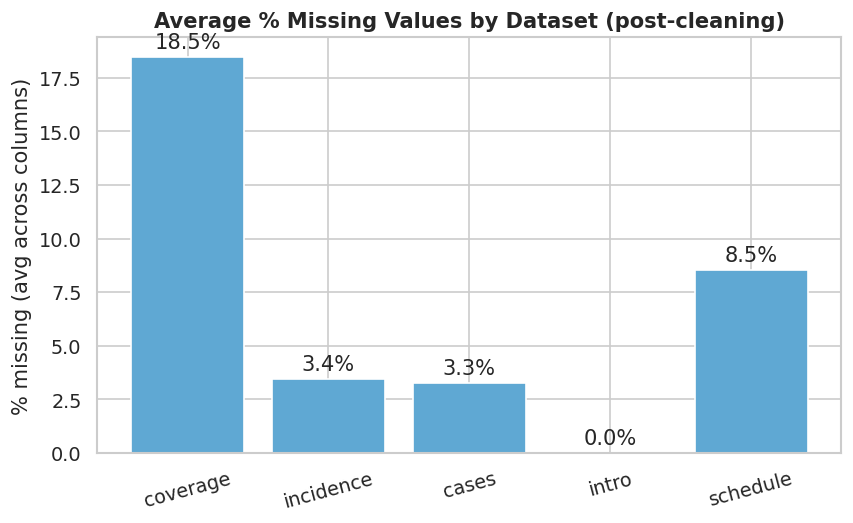

In [21]:
# Chart - 9: Missing Values by Dataset visualization code
miss_pct = {name: df.isnull().mean().mean()*100 for name, df in data.items()}
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(miss_pct.keys(), miss_pct.values(), color=PAL[1])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Average % Missing Values by Dataset (post-cleaning)", fontweight="bold")
ax.set_ylabel("% missing (avg across columns)")
plt.xticks(rotation=15)
plt.show()

##### 1. Why did you pick the specific chart?

A single summary bar chart is the fastest way to communicate overall data completeness across all five tables to a non-technical stakeholder before they trust any downstream KPI.

##### 2. What is/are the insight(s) found from the chart?

The **coverage** table carries the most missingness (concentrated in `TARGET_NUMBER`/`DOSES`/`COVERAGE`, i.e. administrative detail not reported every year), while **vaccine-introduction** and **schedule** tables are close to complete since they record simple categorical/administrative facts rather than annually-reported statistics.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Directly informs the SQL/Power BI build: coverage-derived KPIs should always be computed with an explicit 'reporting countries' denominator (not all 214 countries), otherwise low-reporting years will silently understate true global coverage.

#### Chart - 10: Highest & Lowest Coverage Vaccines (latest year)

_Medium Q: What are the gaps in coverage for vaccines targeting high-priority diseases?_

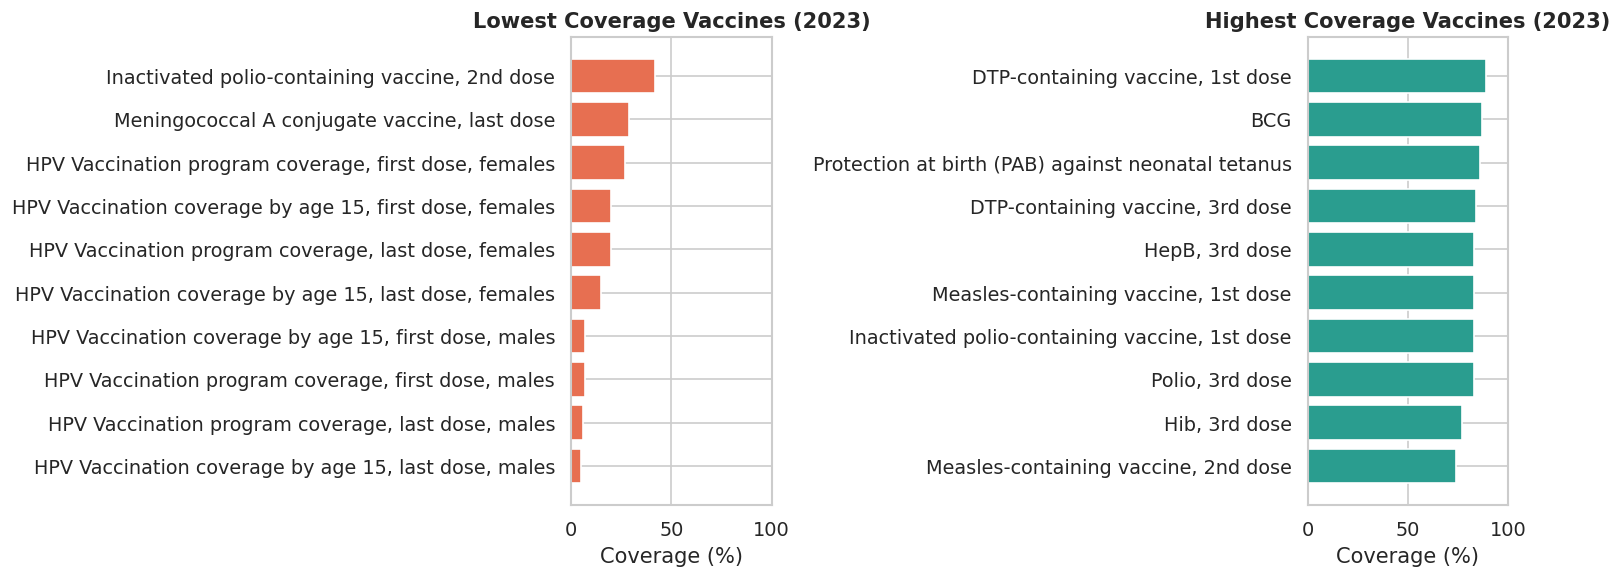

In [22]:
# Chart - 10: Highest & Lowest Coverage Vaccines (latest year) visualization code
latest_cov_year = cov_global["YEAR"].max()
lg = cov_global[cov_global["YEAR"]==latest_cov_year][["ANTIGEN_DESCRIPTION","COVERAGE"]].dropna().drop_duplicates()
lg = lg.sort_values("COVERAGE")
low10, high10 = lg.head(10), lg.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].barh(low10["ANTIGEN_DESCRIPTION"], low10["COVERAGE"], color=PAL[4])
axes[0].set_title(f"Lowest Coverage Vaccines ({int(latest_cov_year)})", fontweight="bold")
axes[1].barh(high10["ANTIGEN_DESCRIPTION"], high10["COVERAGE"], color=PAL[2])
axes[1].set_title(f"Highest Coverage Vaccines ({int(latest_cov_year)})", fontweight="bold")
for ax in axes:
    ax.set_xlabel("Coverage (%)"); ax.set_xlim(0,100)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A paired low/high bar-chart layout immediately contrasts the best- and worst-performing vaccines on the same 0-100% scale, which a single sorted list of 69 antigens would not communicate quickly.

##### 2. What is/are the insight(s) found from the chart?

**HPV vaccination (by age 15) shows the lowest global coverage, in single digits (5-20%)** for both sexes despite HPV vaccines targeting a leading cause of cervical cancer, while legacy EPI vaccines (DTP1 89%, BCG 87%, PAB 86%) remain the highest-coverage antigens globally.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Clear resource-allocation signal: HPV is the single largest coverage gap among tracked vaccines and directly maps to the brief's 'gaps in coverage for vaccines targeting high-priority diseases' question — a strong candidate for a dedicated Power BI KPI card and drill-down page.

#### Chart - 11 - Correlation Heatmap

_Supports: 'How do vaccination rates correlate with a decrease in disease incidence?' across multiple antigen/disease pairs at once_

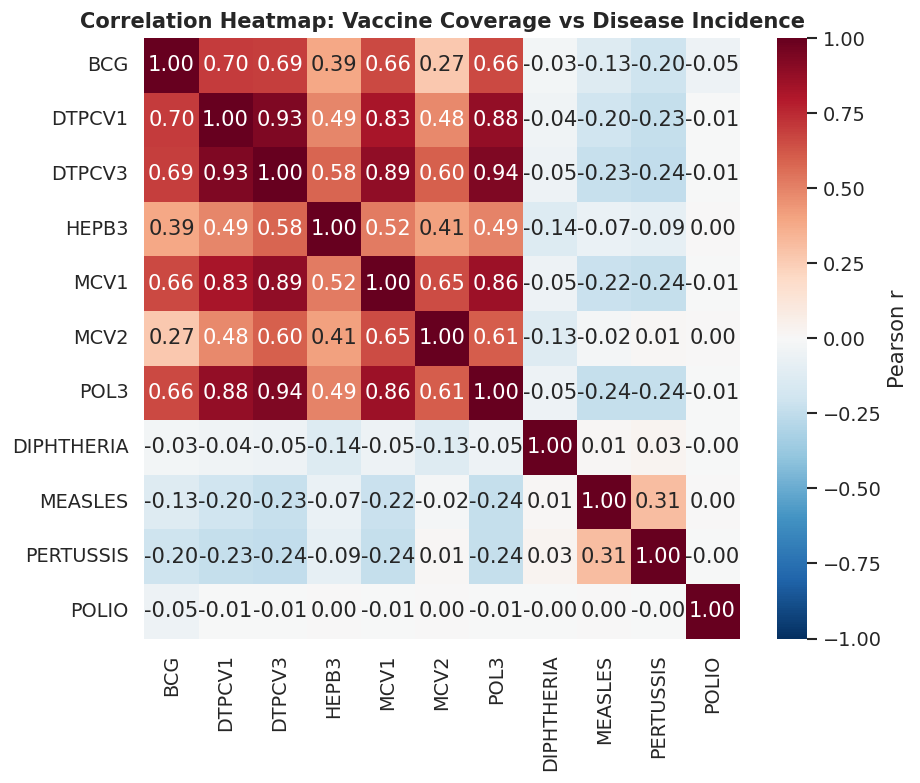

In [23]:
# Chart - 11 - Correlation Heatmap visualization code
wide = cov_country[cov_country["ANTIGEN"].isin(["DTPCV1","DTPCV3","MCV1","MCV2","POL3","BCG","HEPB3"])]
wide_piv = wide.pivot_table(index=["CODE","YEAR"], columns="ANTIGEN", values="COVERAGE", aggfunc="mean")

inc_piv = inc[inc["DISEASE"].isin(["PERTUSSIS","MEASLES","POLIO","DIPHTHERIA"])].pivot_table(
    index=["CODE","YEAR"], columns="DISEASE", values="INCIDENCE_RATE", aggfunc="mean")

merged = wide_piv.join(inc_piv, how="inner")
corr = merged.corr()

fig, ax = plt.subplots(figsize=(8,6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation Heatmap: Vaccine Coverage vs Disease Incidence", fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to scan many pairwise relationships (7 vaccines x 4 diseases, plus vaccine-vaccine relationships) at once, which many individual scatter plots could not do efficiently.

##### 2. What is/are the insight(s) found from the chart?

Coverage across different antigens is **strongly positively correlated with itself** (e.g. DTPCV3 vs POL3 r=0.94, DTPCV1 vs MCV1 r=0.83) — countries that vaccinate well tend to do so across the board, i.e. coverage is a *health-system capacity* signal, not just a per-vaccine one. Coverage-vs-incidence correlations are consistently negative but modest (-0.05 to -0.24), and Measles/Pertussis incidence are themselves positively correlated (r=0.31), suggesting shared underlying drivers (health-system weakness, outbreak clustering, reporting practices).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

For Power BI: a strong system-capacity signal like this supports building one 'Health System Immunization Index' composite score rather than 69 disconnected antigen KPIs — simpler for policymakers to act on.

#### Chart - 12 - Pair Plot

_Supports variable-relationship exploration across key antigens_

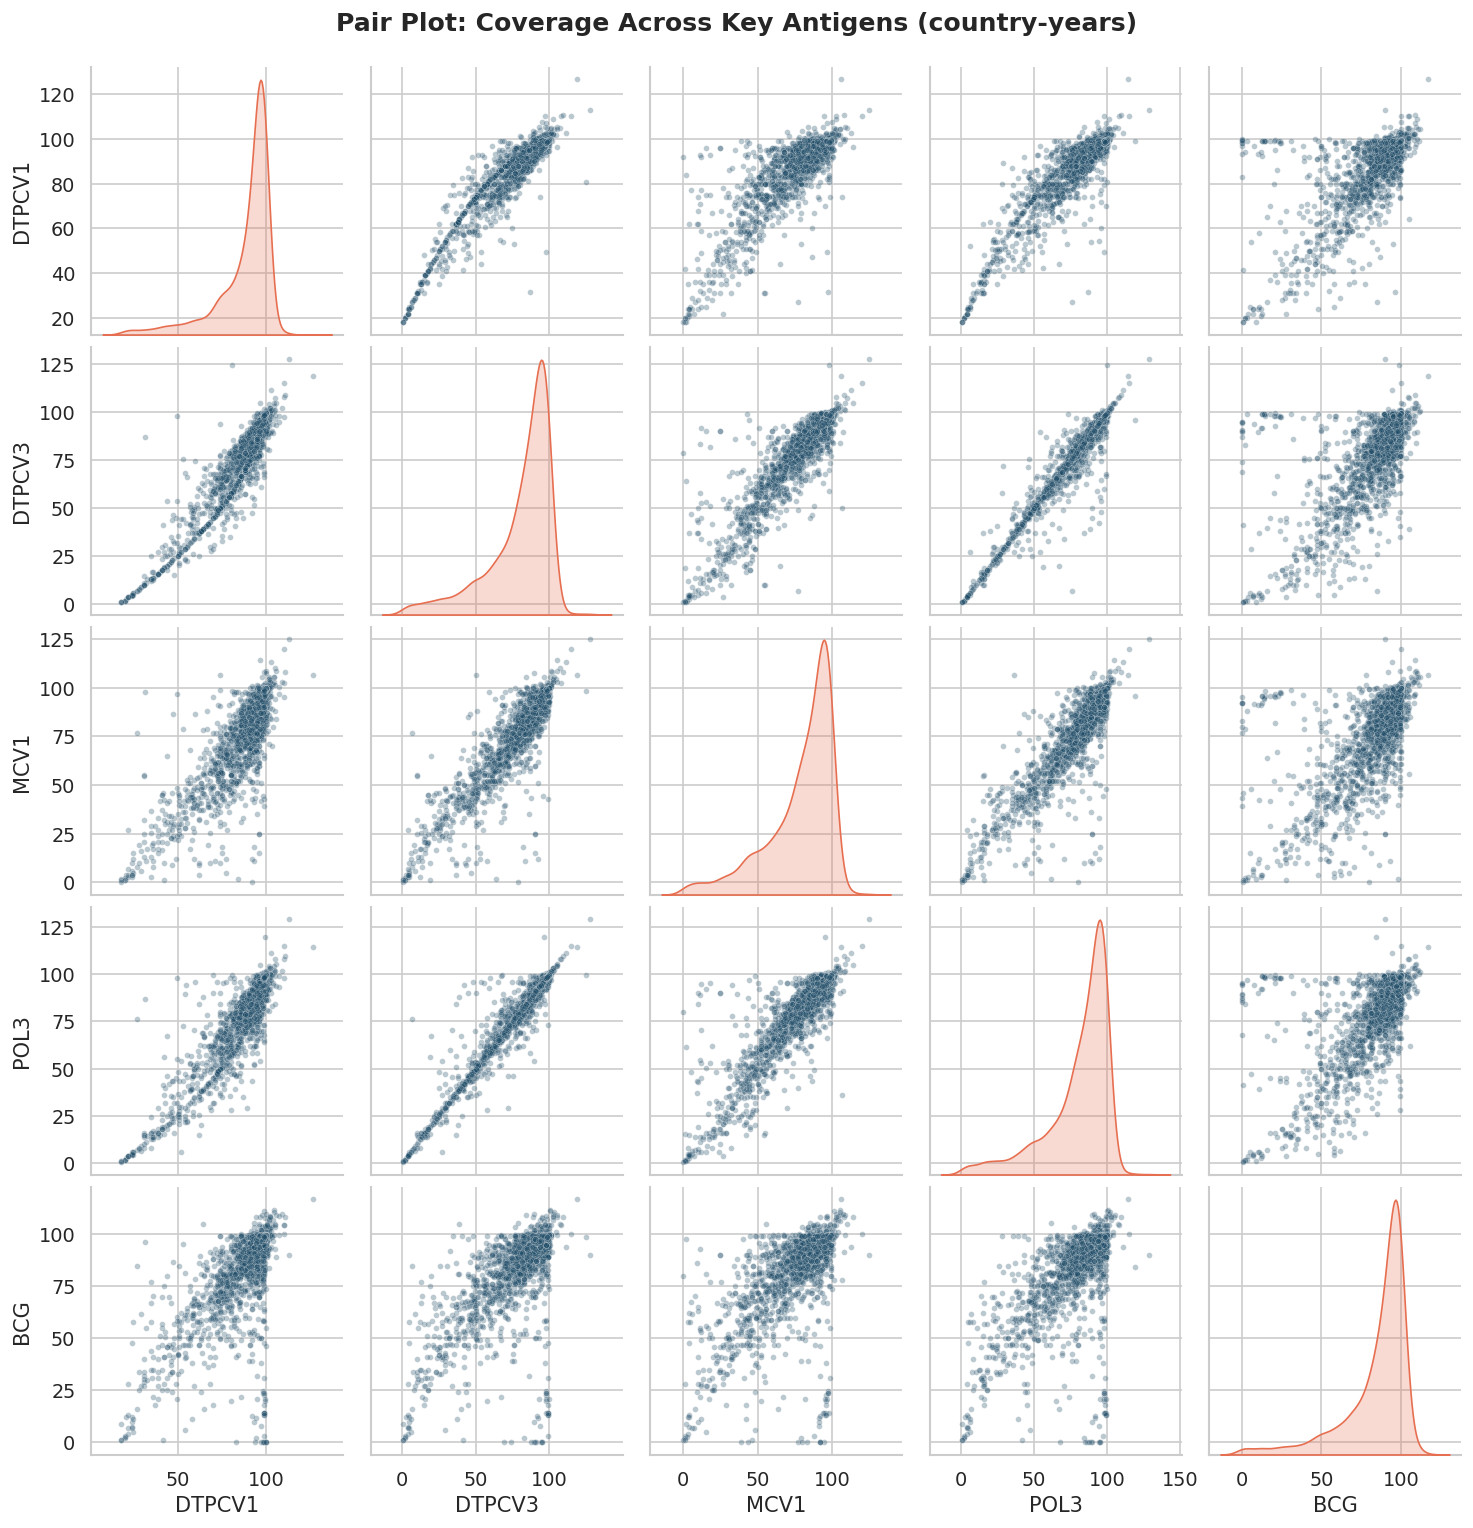

In [24]:
# Chart - 12 - Pair Plot visualization code
pp_df = wide_piv[["DTPCV1","DTPCV3","MCV1","POL3","BCG"]].dropna()
pp_df = pp_df.sample(n=min(2000, len(pp_df)), random_state=42)

g = sns.pairplot(pp_df, diag_kind="kde", plot_kws={"alpha":0.3,"s":12,"color":PAL[0]},
                  diag_kws={"color":PAL[4]})
g.fig.suptitle("Pair Plot: Coverage Across Key Antigens (country-years)", y=1.02, fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise scatter relationship plus each variable's own distribution in a single grid — useful to spot non-linear patterns and clustering that a correlation coefficient alone would hide.

##### 2. What is/are the insight(s) found from the chart?

All five antigens show a similar **left-skewed distribution** (most country-years cluster at high coverage 80-100%, with a long tail down toward 0%), and pairwise scatters are tightly packed along the diagonal — confirming the heatmap finding that countries move together across vaccines rather than doing well on one and poorly on another.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Reinforces the 'systemic capacity, not vaccine-specific' framing: a Power BI dashboard filter for 'countries below X% on any core antigen' would likely surface a similar list of countries regardless of which single antigen is chosen.

#### Chart - 13: Countries with High Coverage but High Measles Incidence

_Scenario Q: Researchers want to explore incidence rates in populations with unexpectedly low protection despite reported coverage._

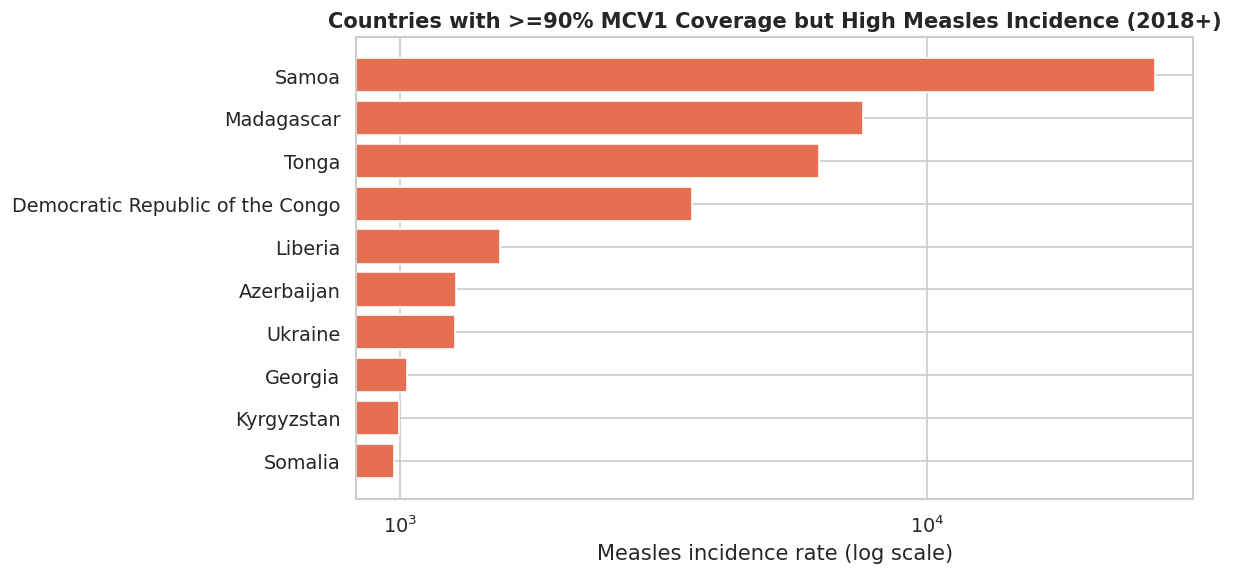

,NAME,YEAR,COVERAGE,INCIDENCE_RATE
20841,Samoa,2019,96.00,27109.4
11966,Madagascar,2019,91.51,7556.1
19094,Tonga,2019,99.00,6236.4
3928,Democratic Republic of the Congo,2019,91.93,3582.9
10870,Liberia,2022,95.86,1544.7
1086,Azerbaijan,2023,96.23,1280.0
19889,Ukraine,2019,93.20,1274.1
6996,Georgia,2019,100.00,1031.9
10048,Kyrgyzstan,2023,96.23,996.1
17320,Somalia,2022,90.68,975.2


In [25]:
mcv1 = cov_country[(cov_country["ANTIGEN"]=="MCV1")][["CODE","NAME","YEAR","COVERAGE"]].dropna()
mea = inc[inc["DISEASE"]=="MEASLES"][["CODE","YEAR","INCIDENCE_RATE"]].dropna()
mm = mcv1.merge(mea, on=["CODE","YEAR"])
mm = mm[mm["YEAR"] >= 2018]
flag = mm[(mm["COVERAGE"]>=90) & (mm["INCIDENCE_RATE"]>1)].sort_values("INCIDENCE_RATE", ascending=False)
flag = flag.drop_duplicates(subset=["NAME"]).head(10)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(flag["NAME"][::-1], flag["INCIDENCE_RATE"][::-1], color=PAL[4])
ax.set_xscale("log")
ax.set_title("Countries with >=90% MCV1 Coverage but High Measles Incidence (2018+)", fontweight="bold")
ax.set_xlabel("Measles incidence rate (log scale)")
plt.show()

flag[["NAME","YEAR","COVERAGE","INCIDENCE_RATE"]]

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart on a log axis makes outlier severity legible when incidence values range from single digits to tens of thousands across countries.

##### 2. What is/are the insight(s) found from the chart?

Samoa, Tonga, Madagascar, DR Congo, and Ukraine all reported **≥90% MCV1 coverage yet experienced major measles outbreaks** (incidence rates in the hundreds to tens of thousands per million) in the same or adjacent year — most of these are documented real-world outbreaks (e.g., the 2019 Samoa measles epidemic), suggesting either overstated national averages masking sub-national/pocket under-vaccination, or below-herd-immunity coverage that still counts as 'high' relative to other vaccines.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative-growth flag: this is the single clearest actionable insight in the analysis — a naive dashboard that shows 'green' at 90%+ national coverage would completely miss these outbreak risks. Recommend a dedicated Power BI alert/KPI using the 95% herd-immunity threshold specifically for measles, plus sub-national coverage data where available, rather than a generic 'coverage above 80% = good' rule used for all vaccines.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Prioritize the African Region** for DTP3/core-EPI coverage investment — it is the only WHO region below 74% and 21 points behind the leading region.
2. **Fund catch-up campaigns to reverse the 2020-2021 pandemic-era coverage decline**, which has not fully recovered by 2023 across nearly every antigen tracked.
3. **Set a measles-specific 95% herd-immunity KPI**, separate from the generic coverage KPI, and flag countries like those in Chart 13 that show high nominal coverage but real outbreak activity.
4. **Treat vaccine introduction and sustained coverage as two separate KPIs** in Power BI — a region (e.g. AFRO) can lead on introducing a new vaccine (Rotavirus) while lagging on sustaining coverage of older ones (DTP3).
5. **Invest specifically in booster/2nd-dose delivery**, not just 1st-dose outreach — the DTP1→DTP3 drop-off and the still-open MCV1→MCV2 gap represent children who are already in the system but not fully protected, typically a cheaper fix than reaching zero-dose children.
6. **Close the HPV coverage gap** (currently single digits to ~20% globally) as a distinct, high-priority initiative given its cervical-cancer prevention impact.
7. Build the recommended Power BI dashboard suite (see the companion **Power BI Dashboard & Business Report**) so these KPIs are monitored continuously rather than through one-off analysis.

# **Conclusion**

This EDA confirms vaccination coverage has broadly risen over four decades and correlates with lower disease incidence, but surfaces three findings that matter more than the top-line trend: (1) the **COVID-19-era coverage decline has not fully reversed**, (2) **regional disparities remain large and specific** (AFRO lowest on sustained coverage, EURO lowest on new-vaccine introduction), and (3) **reported national coverage does not guarantee protection** — several high-coverage countries still experienced serious outbreaks, most visibly for measles. The five source tables do **not** contain gender, education, urban/rural, income, population-density, or monthly-date fields, so those specific brief questions are explicitly out of scope for this dataset rather than answered with assumptions. These findings, and the data limitations, are carried forward directly into the Power BI dashboard design in the companion report.

### ***Analysis complete — see the companion Power BI Dashboard & Business Report for the dashboard designs and full question mapping.***